[Gold, Silver & Precious Metals Futures Daily Data](https://www.kaggle.com/datasets/guillemservera/precious-metals-data)


# STAT5291 Project Code


## Data refresh

From the **repository root** (this folder), regenerate raw downloads and processed CSVs:

```bash
python data_pipeline.py
```

Processed outputs are written under `data/data_processed/`; raw downloads under `data/data_raw/`.
Requires `FRED_API_KEY` in a `.env` file for the HMM feature step.


In [1]:
# Optional: refresh all data from Python (same as CLI above)
%load_ext autoreload
%autoreload 2
import data_pipeline
data_pipeline.run_all()


In [2]:
import pandas as pd
from pathlib import Path

from IPython.display import display

import utility_func

FIGURE_DIR = Path("figure")
DATA_PROCESSED_DIR = utility_func.DATA_PROCESSED_DIR
DATA_RAW_DIR = utility_func.DATA_RAW_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ASSET_LIST = ["Gold", "Silver", "Copper", "Platinum", "Palladium", "sp500"]


# EDA
## Generate time series plot


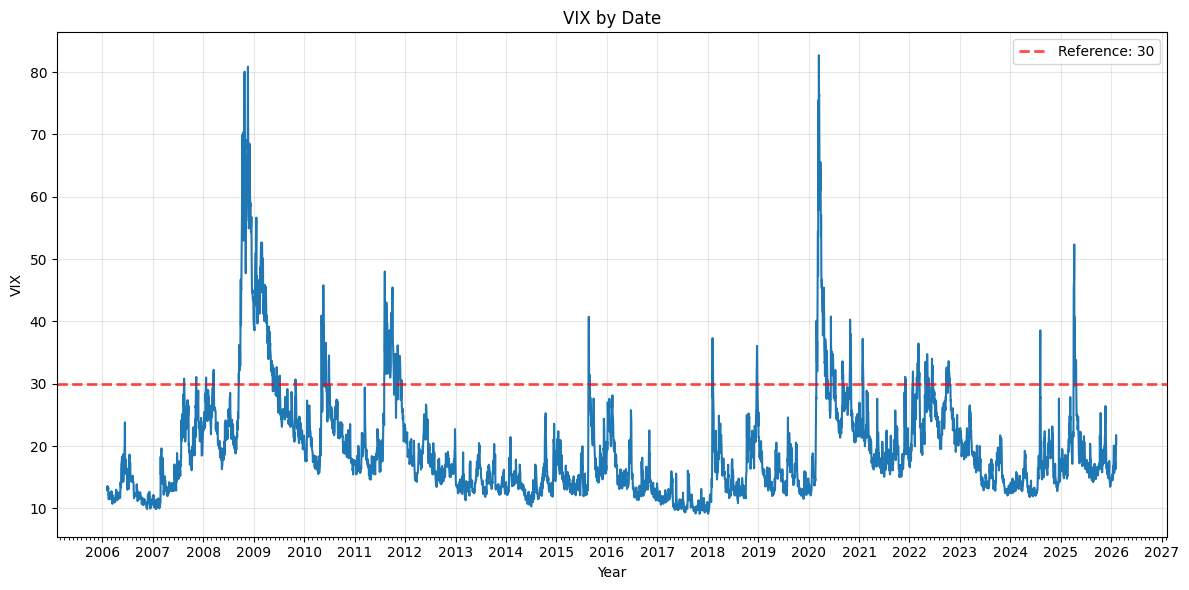

In [3]:
vix_data = pd.read_csv(DATA_RAW_DIR / "vix.csv", parse_dates=["Date"])

utility_func.plot_time_series(
    vix_data,
    date_col="Date",
    value_col="Close",
    title="VIX by Date",
    ylabel="VIX",
    hline=30,
    save_path=FIGURE_DIR / "vix_hline_30.png",
)


## Log return panel


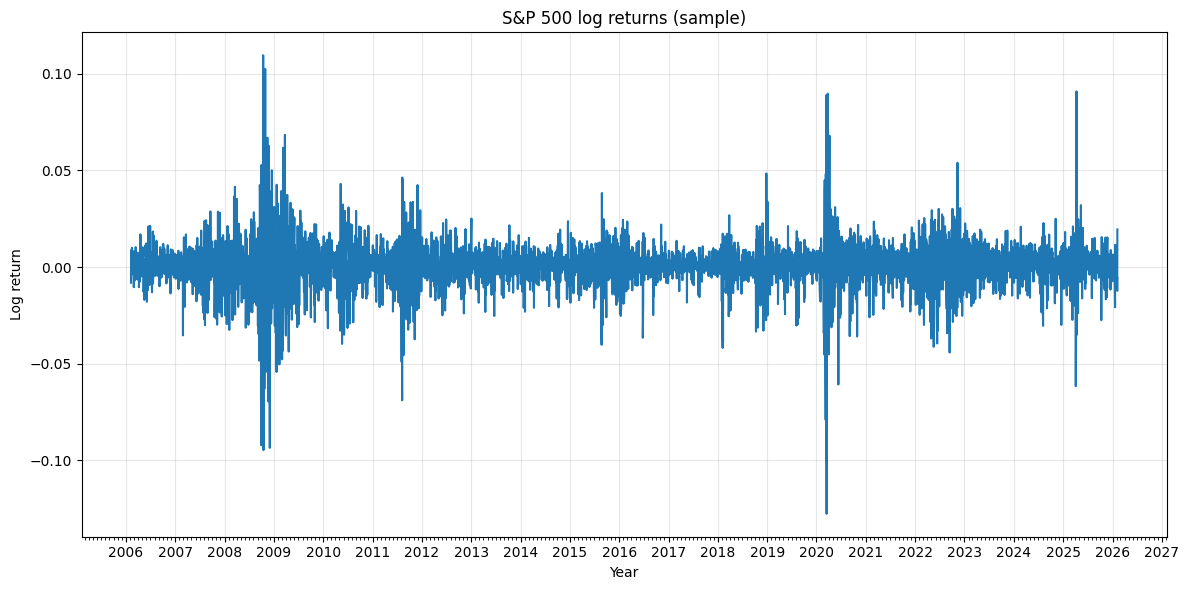

In [4]:
Ret_data = pd.read_csv(DATA_PROCESSED_DIR / "LogRet_data.csv", parse_dates=["Date"])
Ret_data = Ret_data.set_index("Date")
Ret_data.index = pd.to_datetime(Ret_data.index, dayfirst=True)

utility_func.plot_time_series(
    Ret_data.reset_index(),
    date_col="Date",
    value_col="sp500",
    ylabel="Log return",
    title="S&P 500 log returns (sample)",
    save_path=FIGURE_DIR / "sp500_sample.png",
)


## Descriptive statistics


In [5]:
stat_df = utility_func.descriptive_stats_by_regime(Ret_data, ASSET_LIST)
display(stat_df)


Days  Return  Volatility  Skewness  Kurtosis
Asset     Regime                                                         
Gold      Normal(VIX < 30)   4590  0.1022      0.1682   -0.9337    8.3335
          Extreme(VIX > 30)   447  0.1421      0.2988    0.3104    1.8273
          Overall            5037  0.1057      0.1835   -0.5296    7.2688
Silver    Normal(VIX < 30)   4590  0.1395      0.3248   -1.8544   29.2043
          Extreme(VIX > 30)   447 -0.3190      0.5495   -0.5904    3.4590
          Overall            5037  0.0987      0.3507   -1.5750   22.0410
Copper    Normal(VIX < 30)   4590  0.1411      0.2546   -0.6917   15.7740
          Extreme(VIX > 30)   447 -0.9088      0.4798   -0.0182    1.3026
          Overall            5037  0.0478      0.2826   -0.5874   11.4667
Platinum  Normal(VIX < 30)   4590  0.0895      0.2598   -0.8737   11.4989
          Extreme(VIX > 30)   447 -0.8584      0.4114   -0.5104    3.6132
          Overall            5037  0.0215      0.2739   -0.8749   10.3758
Palladium Normal(VIX < 30)   4590  0.1697      0.3458   -0.3928    5.2314
          Extreme(VIX > 30)   447 -0.9920      0.5966   -0.3689    7.7077
          Overall            5037  0.0648      0.3759   -0.4910    8.5344
sp500     Normal(VIX < 30)   4590  0.1869      0.1414   -0.1930    2.1118
          Extreme(VIX > 30)   447 -0.9351      0.4692    0.0427    1.8861
          Overall            5037  0.0871      0.1954   -0.4779   12.8531

## Visualization
### Scatterplot by regime


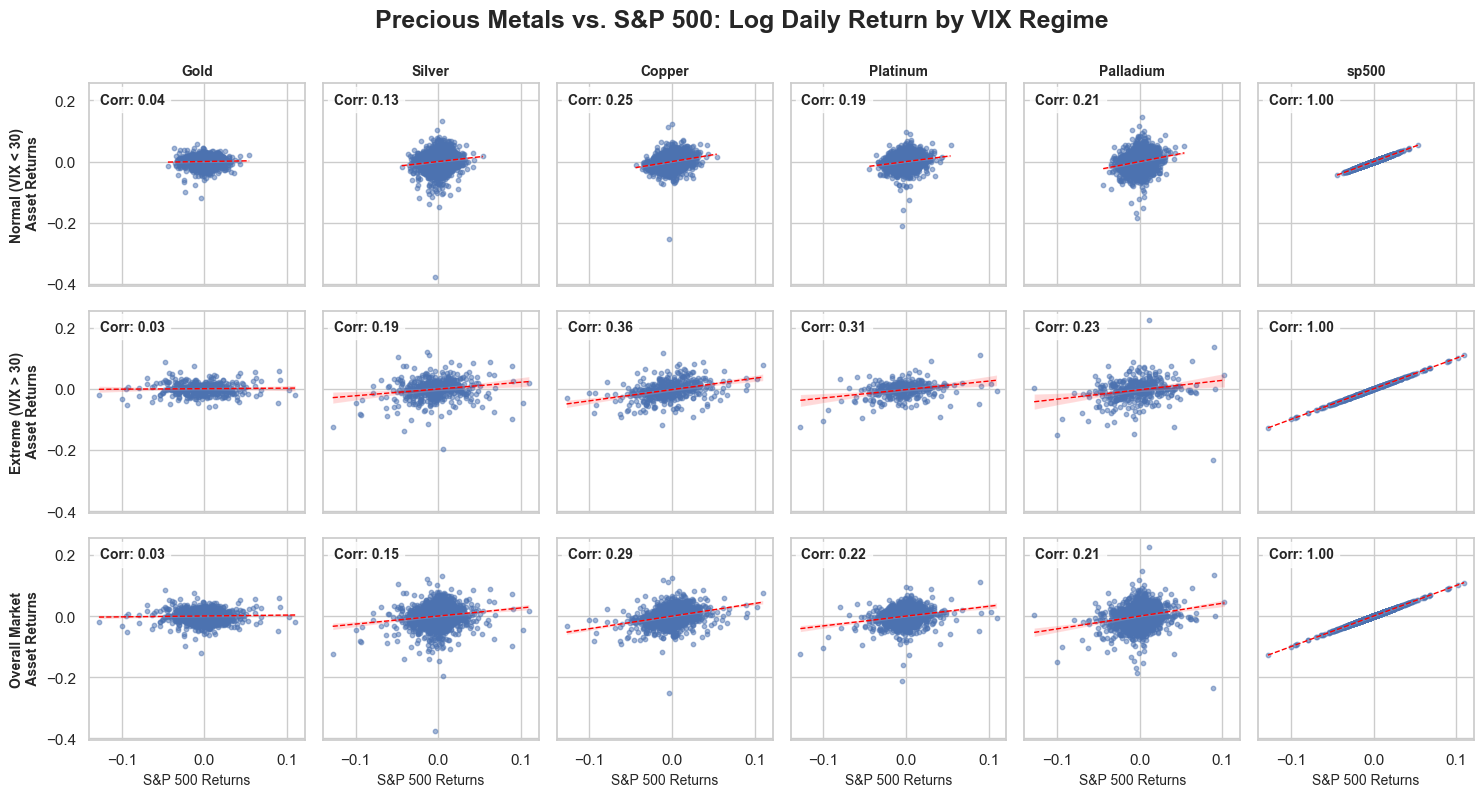

In [6]:
utility_func.plot_regime_scatter_grid(Ret_data, ASSET_LIST, FIGURE_DIR)


### QQ-plot


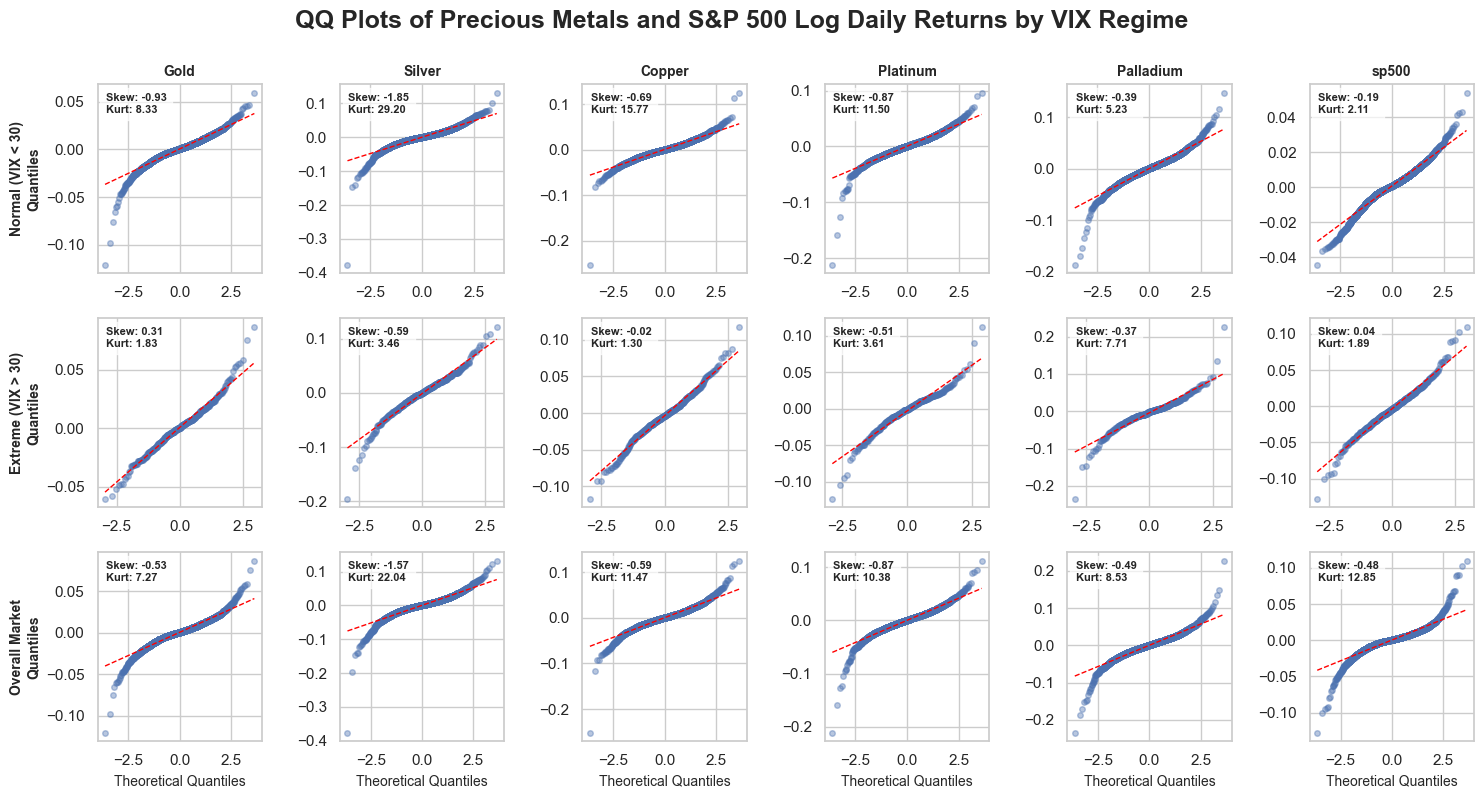

In [7]:
utility_func.plot_qq_by_regime(Ret_data, ASSET_LIST, FIGURE_DIR, layout="regime_rows")


In [8]:
events_df = pd.read_csv(utility_func.ROOT/ "data" / "global_market_stress_events.csv")
display(events_df.head())

,Event Name,Abbreviation,Start Date,End Date
0,Global Financial Crisis,GFC,15/8/2007,8/7/2009
1,Flash Crash & Eurozone Crisis I,EZC-I,6/5/2010,2/7/2010
2,US Credit Rating Downgrade,US-DWN,4/8/2011,8/12/2011
3,China Market Turbulence,CHN-VOL,24/8/2015,1/9/2015
4,Volmageddon & Late-Cycle Correction,VOL-MAX,5/2/2018,26/12/2018


### Rolling correlation


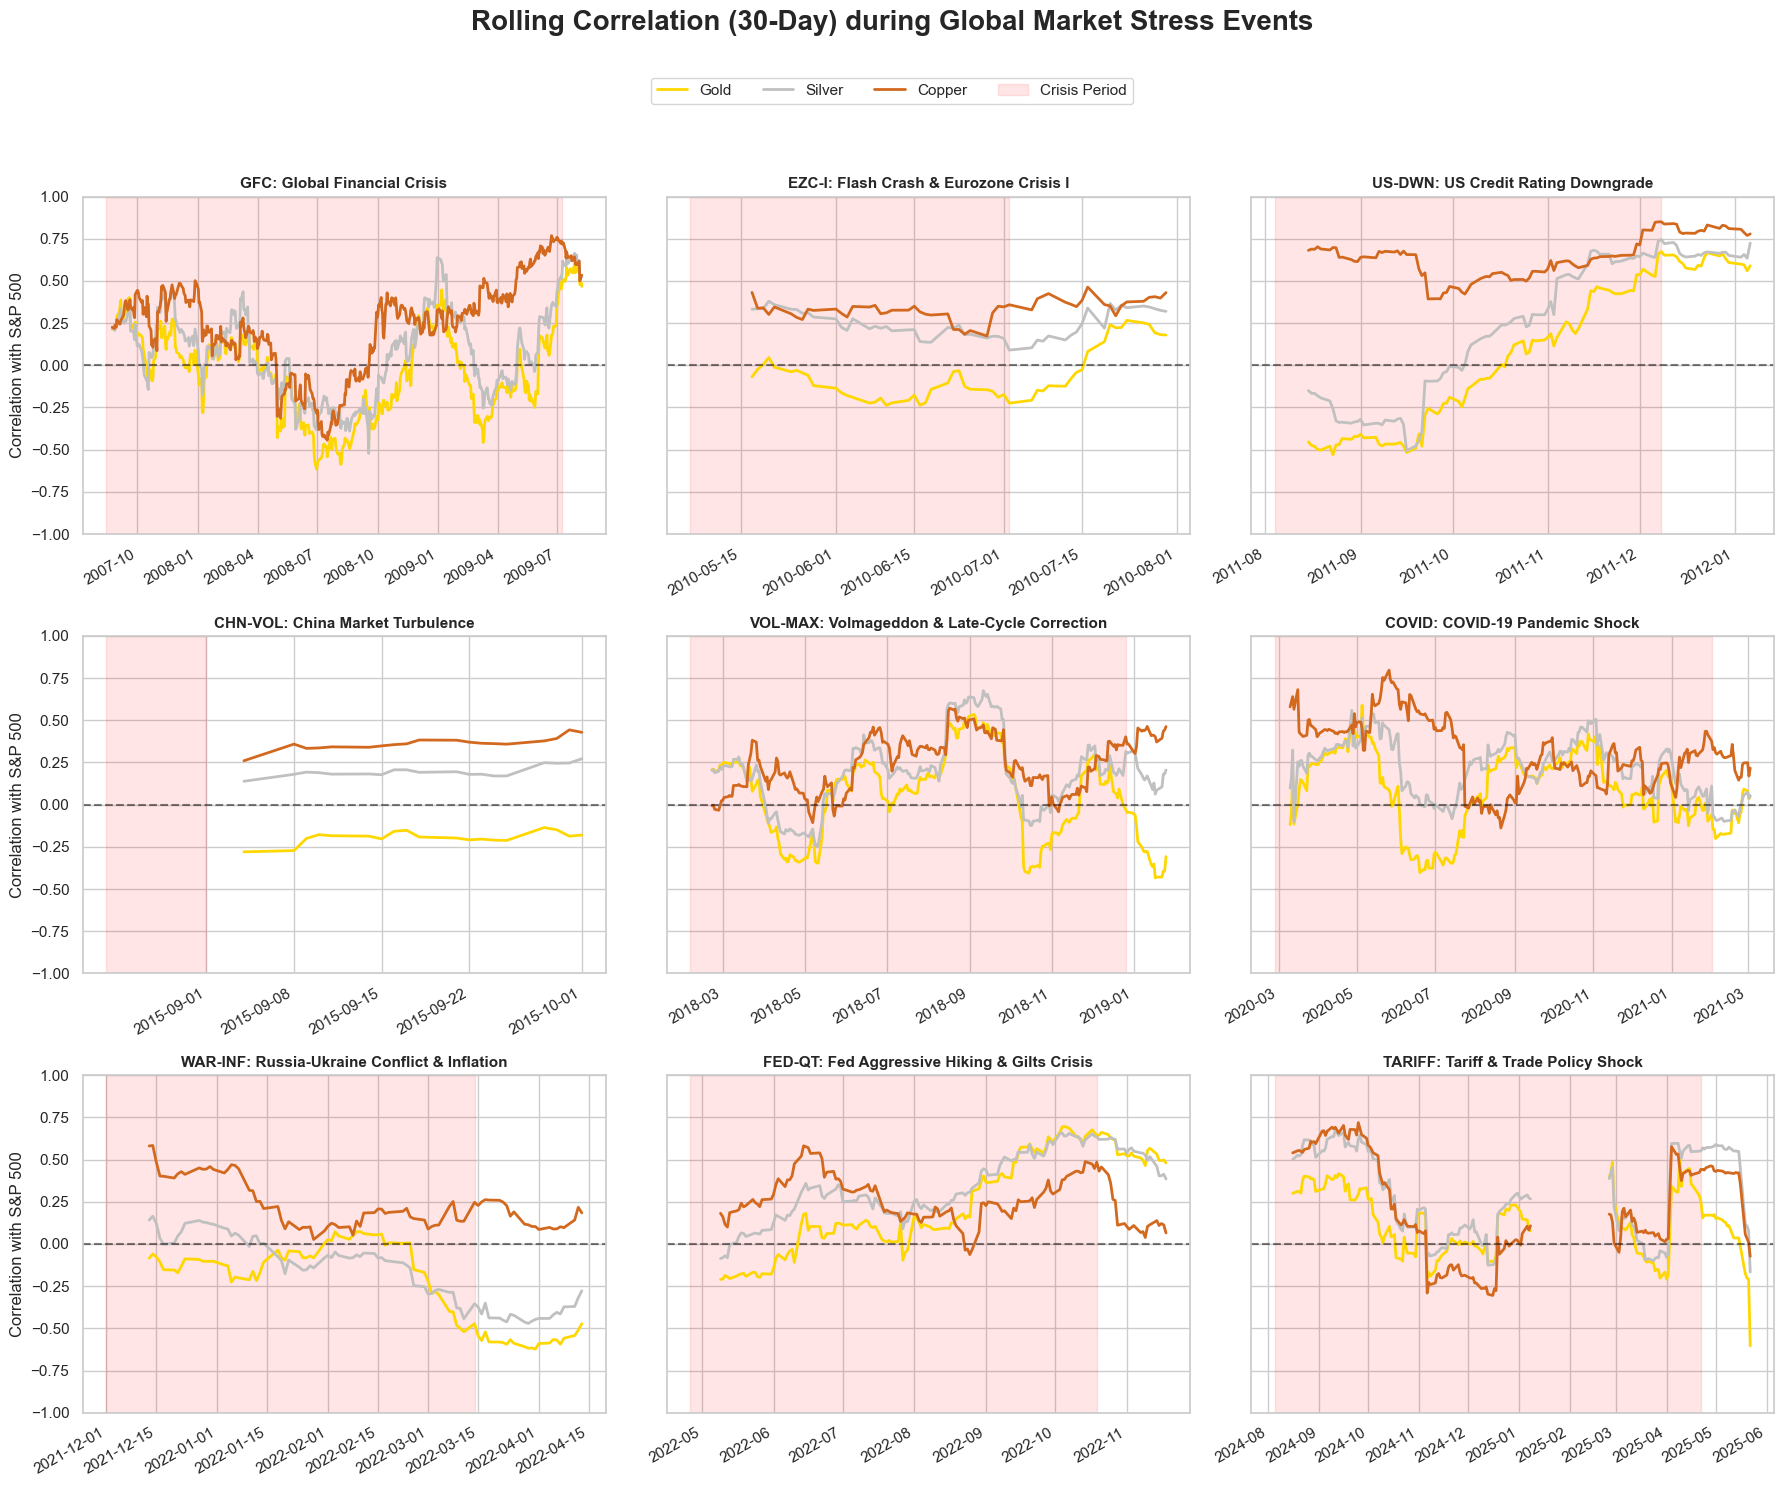

In [9]:
utility_func.plot_rolling_corr_stress_events(Ret_data, events_df, FIGURE_DIR)

### Maximum drawdown comparison


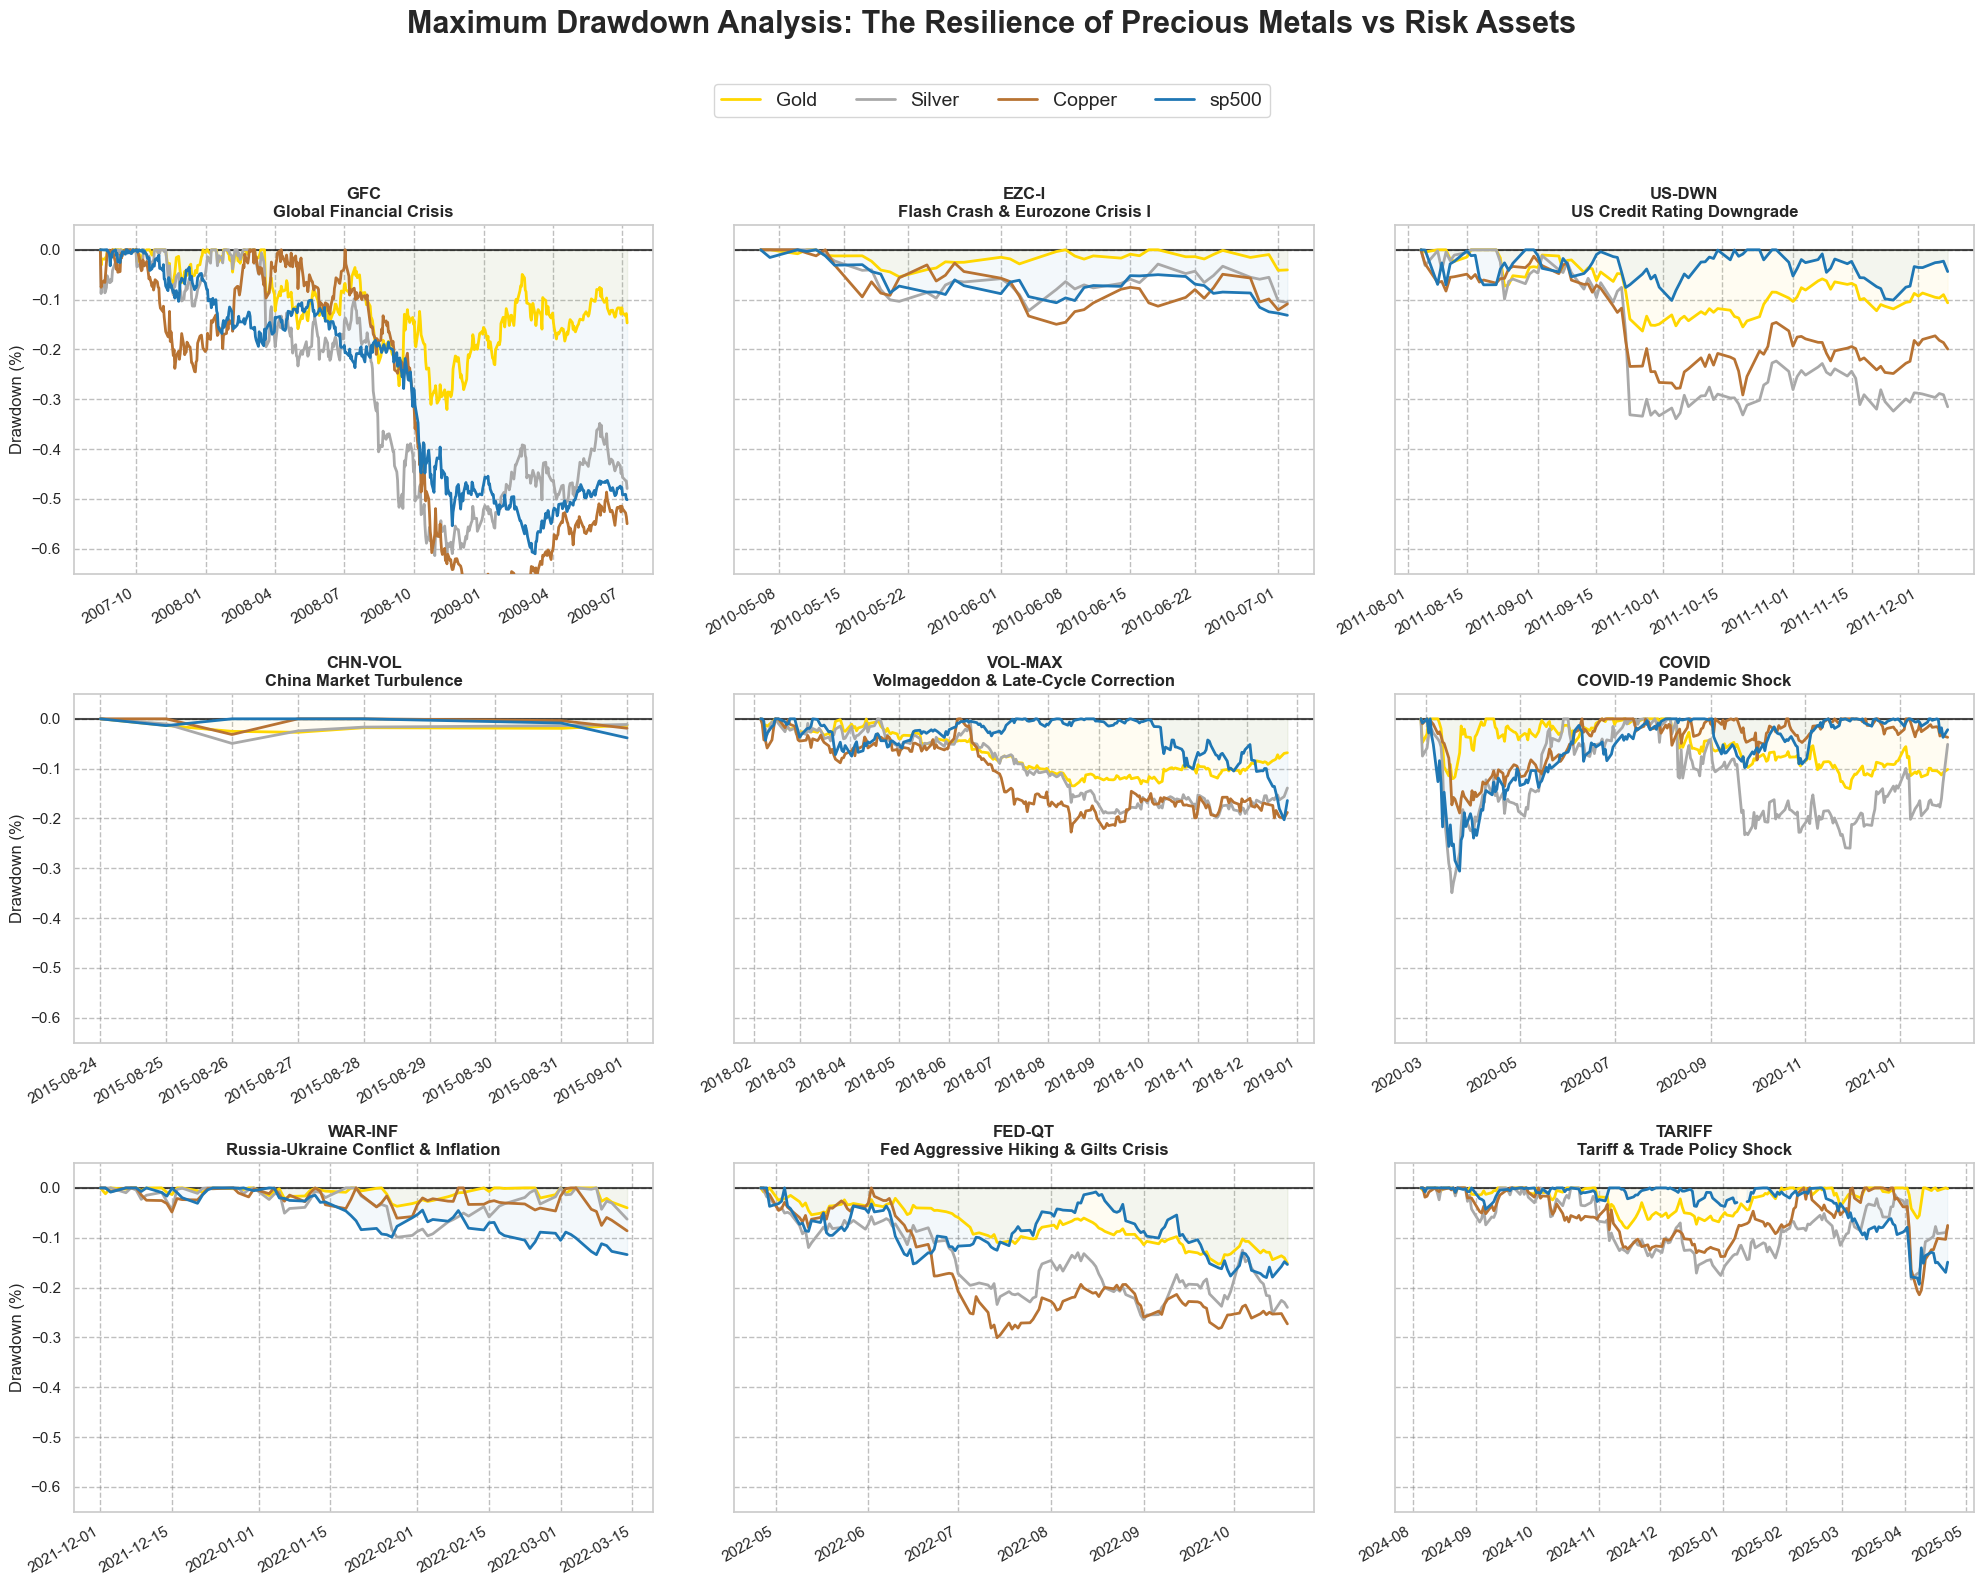

In [10]:
utility_func.plot_drawdown_stress_events(Ret_data, events_df, FIGURE_DIR)


# HMM


## Prepare HMM dataset

Features are built by `data_pipeline.py` into `data/data_processed/HMM_features.csv` (FRED DFII10 / T10YIE, gold ratios, log returns aligned to `LogRet_data.csv` dates).


In [11]:
hmm_path = DATA_PROCESSED_DIR / "HMM_features.csv"
feat_df = pd.read_csv(hmm_path, parse_dates=["Date"])
display(pd.DataFrame({"rows": [feat_df.shape[0]], "cols": [feat_df.shape[1]]}))
display(feat_df.head())
display(feat_df.tail())


,rows,cols
0,5037,9


,Date,DFII10,T10YIE,gold_oil_ratio,gold_copper_ratio,gold_log_ret,sp500_log_ret,gold_egarch_vol,sp500_egarch_vol
0,2006-02-07,2.02,2.55,8.733555,240.874327,-0.034252,-0.008128,0.015952,0.005796
1,2006-02-08,2.07,2.49,8.794564,241.271922,-0.001635,0.008626,0.016970,0.006986
2,2006-02-09,2.05,2.49,9.014692,244.478127,0.025840,-0.001479,0.016201,0.006698
3,2006-02-10,2.09,2.50,8.897154,247.169809,-0.025659,0.002537,0.017266,0.006619
4,2006-02-13,2.08,2.50,8.801437,240.947699,-0.020566,-0.003265,0.017722,0.006291


,Date,DFII10,T10YIE,gold_oil_ratio,gold_copper_ratio,gold_log_ret,sp500_log_ret,gold_egarch_vol,sp500_egarch_vol
5032,2026-02-02,1.94,2.35,74.388478,796.776717,-0.019580,0.005377,0.023863,0.007465
5033,2026-02-03,1.92,2.36,77.577919,808.857764,0.059054,-0.008439,0.023537,0.007097
5034,2026-02-04,1.94,2.35,75.535768,844.558826,0.003400,-0.005085,0.026704,0.008194
5035,2026-02-05,1.89,2.32,76.811500,838.316965,-0.012063,-0.012327,0.025378,0.008574
5036,2026-02-06,1.88,2.34,77.910311,844.410351,0.018304,0.019504,0.024561,0.010231


### Introduce EGARCH model as a feature in HMM
EGARCH:
$$\log\sigma_t^2=\omega + \beta\log\sigma^2_{t-1} + \alpha(|z_{t-1}-E|z_{t-1}|)+ \gamma z_{t-1}$$


## Feature engineering and in-sample fit


State conditional means:
    gold_log_ret  sp500_log_ret  diff_DFII10  d_gold_copper  gold_egarch_vol  \
0      0.000457       0.000910    -0.000007      -0.000164         0.009578   
1      0.000411      -0.000776    -0.000278       0.001518         0.013754   

   sp500_egarch_vol  
0          0.007766  
1          0.015044  
State 0 covariance:
 [[ 0.54821186  0.02372251 -0.16133485  0.17948541  0.00904863  0.00222485]
 [ 0.02372251  0.3293867   0.03323151 -0.10941824  0.00976478  0.02980047]
 [-0.16133485  0.03323151  0.63607536 -0.12230417  0.0054094   0.00102329]
 [ 0.17948541 -0.10941824 -0.12230417  0.560984   -0.01543462 -0.01488612]
 [ 0.00904863  0.00976478  0.0054094  -0.01543462  0.28245104  0.02857692]
 [ 0.00222485  0.02980047  0.00102329 -0.01488612  0.02857692  0.1478375 ]]
State 1 covariance:
 [[ 1.90791837  0.03635537 -0.29900444  0.56645746 -0.01486604  0.02074071]
 [ 0.03635537  2.33499883  0.26421673 -0.5735889   0.07633541  0.09546225]
 [-0.29900444  0.26421673  

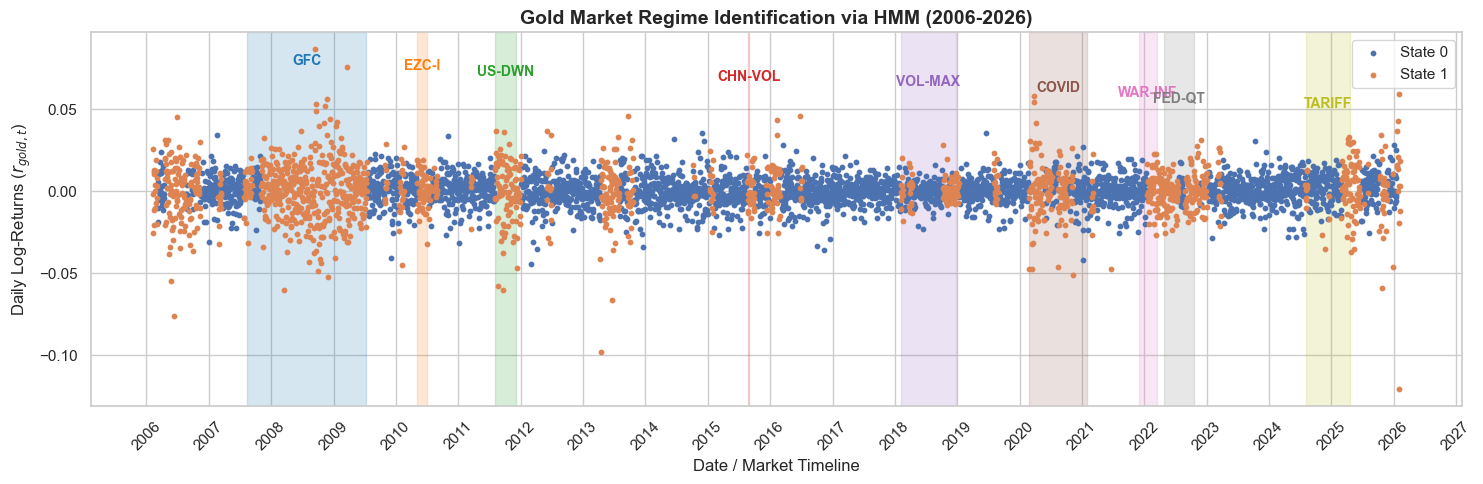

Feature sp500_egarch_vol discriminative score: 0.7742
Feature gold_egarch_vol discriminative score: 0.7458
Feature sp500_log_ret discriminative score: 0.0656
Feature d_gold_copper discriminative score: 0.0450
Feature diff_DFII10 discriminative score: 0.0024
Feature gold_log_ret discriminative score: 0.0019


In [12]:
import importlib


importlib.reload(utility_func)
df_model, X, scaler, features = utility_func.prepare_hmm_design_matrix(hmm_path)
model, df_model = utility_func.fit_gaussian_hmm_assign_states(
    df_model, X, features, scaler, random_state=42
)
utility_func.print_hmm_training_summaries(model, scaler, features)
utility_func.plot_hmm_gold_states_scatter(
    df_model, model,
    crisis_events_path="data/global_market_stress_events.csv",
)
utility_func.print_discriminative_feature_scores(model, features)


In [15]:
model.transmat_

array([[0.98353856, 0.01646144],
       [0.03310117, 0.96689883]])

## Model testing
### Walk-forward and economic value


          sp500_log_ret           gold_log_ret          
                   mean       std         mean       std
OOS_State                                               
0              0.000591  0.010100     0.000167  0.010865
1              0.000325  0.011878     0.000499  0.010300
OOS state 0 correlation: -0.0019
OOS state 1 correlation: 0.0699


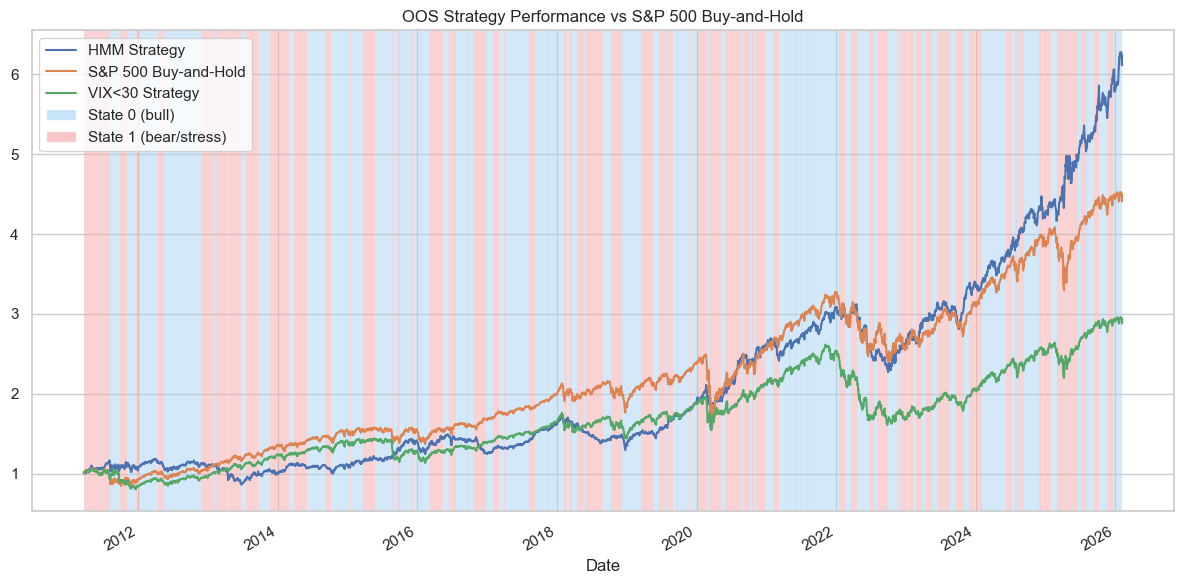

In [13]:
df_oos = utility_func.walk_forward_hmm_oos(X, df_model, random_state=0)
df_oos = utility_func.merge_oos_with_returns(df_oos, df_model)
utility_func.print_oos_summary(df_oos)
df_oos = utility_func.add_regime_strategy_returns(df_oos)
utility_func.plot_strategy_vs_buyhold(df_oos)


          sp500_log_ret           gold_log_ret          
                   mean       std         mean       std
OOS_State                                               
0              0.000341  0.013711     0.000471  0.011568
1              0.000543  0.008953     0.000233  0.010000
OOS state 0 correlation: 0.0766
OOS state 1 correlation: -0.0118


c:\Users\jimmy\OneDrive\University\2025-26\STAT5291\Capstone\utility_func.py:883: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


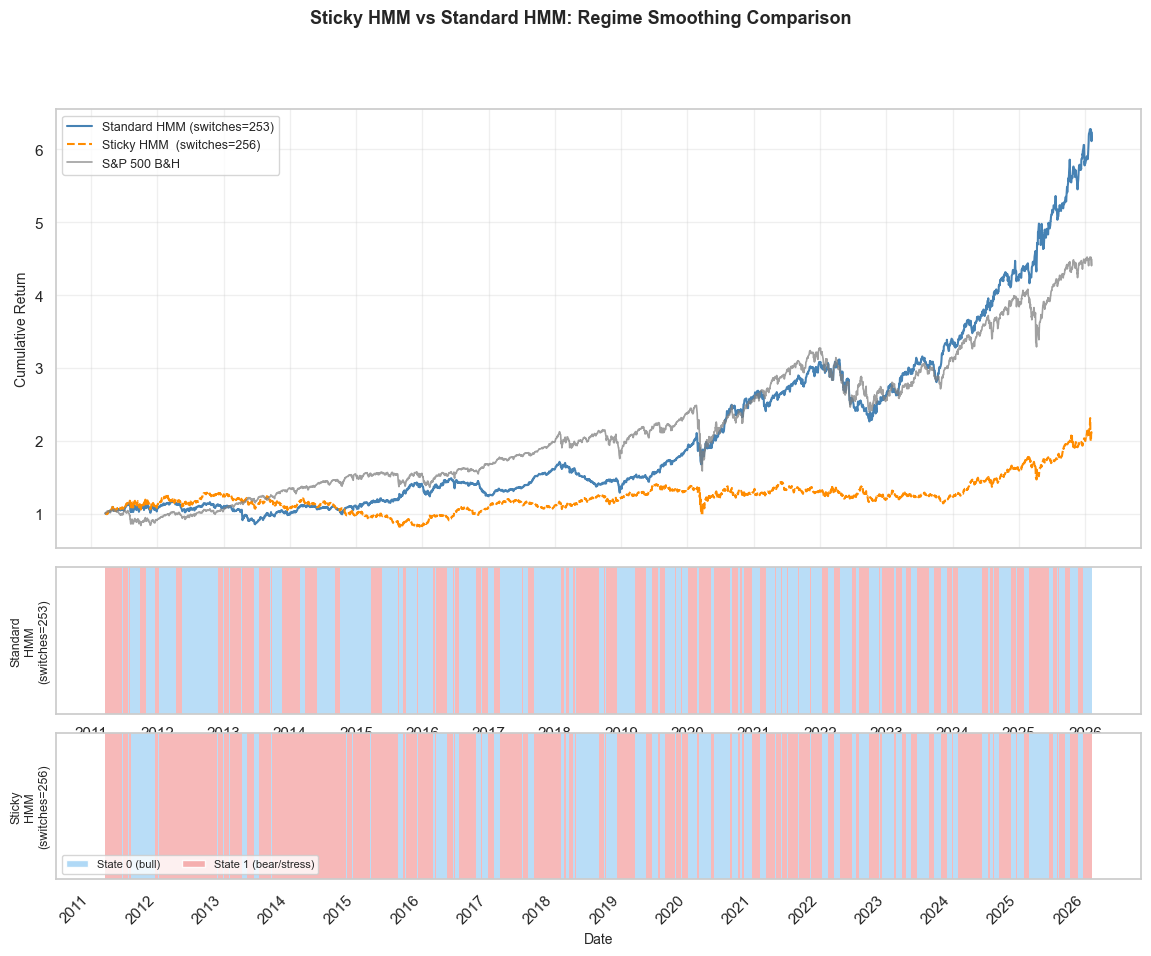

In [14]:
## Sticky HMM — smoother regime transitions
# p_stay=0.97 means each state has a 97% self-transition prior,
# discouraging rapid regime switches.
# importlib.reload(utility_func)

df_oos_sticky = utility_func.walk_forward_sticky_hmm_oos(
    X, df_model, random_state=0, p_stay=0.99
)
df_oos_sticky = utility_func.merge_oos_with_returns(df_oos_sticky, df_model)
utility_func.print_oos_summary(df_oos_sticky)
df_oos_sticky = utility_func.add_regime_strategy_returns(df_oos_sticky)
utility_func.plot_sticky_vs_standard_comparison(df_oos, df_oos_sticky)


# GARCH-X Volatility Spillover

## Background

To complement the return-based baseline models, we estimate symmetric and asymmetric GARCH-based volatility spillover models to examine whether stock-market shocks transmit into Gold's conditional volatility. The results provide strong evidence of volatility spillover. In the symmetric specification, the coefficient on lagged absolute S&P 500 returns is positive and highly significant (gamma = 0.380, p < 0.001), indicating that larger stock-market moves are associated with higher Gold volatility on the following day. In the asymmetric specification, both lagged positive and lagged negative stock returns are positive and highly significant (gamma_pos = 0.401, gamma_neg = 0.364, both p < 0.001), which shows that both rallies and selloffs in equities increase Gold volatility. However, the positive-return coefficient is slightly larger than the negative-return coefficient, so the evidence supports broad volatility spillover rather than a clearly stronger downside-only contagion effect.

The conditional volatility plots further suggest that Gold's estimated volatility rises sharply around major stress episodes, indicating that the GARCH framework is capturing crisis-period risk dynamics. At the same time, the standardized residual diagnostics show that important distributional features remain unresolved. The standardized residuals are centered close to zero and have variance close to one, but kurtosis remains high at about 6.74 and the Jarque-Bera test strongly rejects normality (p approximately 0). This means the GARCH model successfully captures volatility clustering, but it does not fully absorb the heavy tails and extreme-return behavior in Gold. Overall, these results suggest that Gold is not volatility-insulated from stock-market turbulence: equity shocks do spill over into Gold's risk, although the remaining fat tails also indicate that more flexible methods such as quantile regression and HMM are still needed to study tail behavior and regime dependence more fully.

In [ ]:
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera, kurtosis
from IPython.display import HTML

In [ ]:
# GARCH-X baseline data
garch_df = Ret_data[["Gold", "sp500"]].copy()
garch_df = garch_df.rename(columns={"Gold": "gold_ret", "sp500": "sp500_ret"})
garch_df = garch_df.dropna(subset=["gold_ret", "sp500_ret"]).copy()

# convert to percent scale for numerical stability in GARCH estimation
garch_df["gold_ret_pct"] = 100 * garch_df["gold_ret"]
garch_df["sp500_ret_pct"] = 100 * garch_df["sp500_ret"]

# symmetric spillover regressor
garch_df["sp500_abs_lag1"] = garch_df["sp500_ret_pct"].abs().shift(1)

# asymmetric spillover regressors
garch_df["sp500_pos_lag1"] = garch_df["sp500_ret_pct"].clip(lower=0).shift(1)
garch_df["sp500_neg_lag1"] = (-garch_df["sp500_ret_pct"].clip(upper=0)).shift(1)  # positive magnitude of downside move

garch_df.head()

In [ ]:
# Helper functions
def fit_garchx(y, X, p=1, q=1, dist="t", mean="Constant"):
    """
    Fit GARCH-X using arch_model with exogenous regressors in mean equation if needed.
    Since arch_model does not directly allow exogenous regressors in variance equation
    in the standard interface, we fit a mean model first and then fit GARCH on residuals
    with external regressors through a custom two-step proxy approach.

    For a direct spillover design consistent with your project, we model:
    1) mean equation for gold return as constant
    2) volatility relation assessed by regressing fitted conditional variance proxy on exogenous variables

    However, arch also supports exogenous regressors in the mean equation via x=...
    Here we keep mean simple and focus on volatility interpretation.
    """
    am = arch_model(
        y,
        mean=mean,
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    res = am.fit(disp="off")
    return res


def fit_garchx_proxy(df, y_col, x_cols, p=1, q=1, dist="t"):
    """
    Practical reusable workflow:
    Step 1: Fit baseline GARCH(1,1) to Gold return
    Step 2: Use standardized residual / conditional volatility outputs
    Step 3: Estimate spillover relation via variance proxy regression

    This is a practical notebook-friendly implementation if you want clean workflow
    without custom ML estimation.

    Returns:
        result_dict with fitted objects and joined output dataframe
    """
    sample = df[[y_col] + x_cols].dropna().copy()

    y = sample[y_col]
    am = arch_model(
        y,
        mean="Constant",
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    garch_res = am.fit(disp="off")

    out = sample.copy()
    out["cond_var"] = garch_res.conditional_volatility ** 2
    out["cond_vol"] = garch_res.conditional_volatility
    out["resid"] = garch_res.resid
    out["std_resid"] = garch_res.std_resid

    return {
        "sample": sample,
        "garch_res": garch_res,
        "output_df": out
    }


def run_variance_proxy_regression(df, y_col="cond_var", x_cols=None):
    """
    OLS-style variance proxy regression to evaluate spillover significance cleanly.
    """
    import statsmodels.api as sm

    reg_df = df[[y_col] + x_cols].dropna().copy()
    X = sm.add_constant(reg_df[x_cols])
    y = reg_df[y_col]

    model = sm.OLS(y, X).fit(cov_type="HC3")
    return model


def build_distribution_gap_report(std_resid, label="Model"):
    """
    Summarize residual non-normality after GARCH filtering
    using SciPy's jarque_bera and kurtosis.
    """
    std_resid = pd.Series(std_resid).dropna()

    # SciPy Jarque-Bera
    jb_res = jarque_bera(std_resid)

    # compatible with different SciPy return styles
    if hasattr(jb_res, "statistic") and hasattr(jb_res, "pvalue"):
        jb_stat = jb_res.statistic
        jb_p = jb_res.pvalue
    else:
        jb_stat = jb_res[0]
        jb_p = jb_res[1]

    # Pearson kurtosis: normal = 3
    ex_kurt = kurtosis(std_resid, fisher=False, bias=False)

    report = pd.DataFrame({
        "Model": [label],
        "N": [len(std_resid)],
        "StdResid Mean": [std_resid.mean()],
        "StdResid Std": [std_resid.std()],
        "Kurtosis": [ex_kurt],
        "Jarque-Bera Stat": [jb_stat],
        "Jarque-Bera p-value": [jb_p]
    })

    return report


def plot_conditional_volatility(output_df, title, event_lines=None, figsize=(14, 5)):
    """
    Plot conditional volatility time series.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(output_df.index, output_df["cond_vol"], linewidth=1.2)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Conditional Volatility")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)

    if event_lines is not None:
        for dt, lbl in event_lines:
            ax.axvline(pd.to_datetime(dt), linestyle="--", alpha=0.7)
            ax.text(pd.to_datetime(dt), ax.get_ylim()[1] * 0.95, lbl,
                    rotation=90, va="top", ha="right", fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_std_resid_diagnostics(std_resid, title_prefix="Standardized Residuals"):
    """
    Quick diagnostic visuals for standardized residuals.
    """
    std_resid = pd.Series(std_resid).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(std_resid, bins=40)
    axes[0].set_title(f"{title_prefix}: Histogram")
    axes[0].set_xlabel("Standardized Residual")
    axes[0].set_ylabel("Frequency")

    sns.boxplot(x=std_resid, ax=axes[1])
    axes[1].set_title(f"{title_prefix}: Boxplot")
    axes[1].set_xlabel("Standardized Residual")

    plt.tight_layout()
    plt.show()

In [ ]:
# Event lines for volatility spike plot
event_lines = [
    ("2008-09-15", "GFC"),
    ("2020-03-11", "COVID"),
    ("2022-02-24", "WAR-INF")
]

In [ ]:
# Symmetric volatility spillover block
sym_x_cols = ["sp500_abs_lag1"]

sym_fit = fit_garchx_proxy(
    df=garch_df,
    y_col="gold_ret_pct",
    x_cols=sym_x_cols,
    p=1,
    q=1,
    dist="t"
)

sym_out = sym_fit["output_df"]
sym_garch_res = sym_fit["garch_res"]

sym_var_model = run_variance_proxy_regression(
    df=sym_out,
    y_col="cond_var",
    x_cols=sym_x_cols
)

display(HTML("<h3>Symmetric GARCH Baseline Summary</h3>"))
display(HTML(sym_garch_res.summary().as_html()))

display(HTML("<h3>Symmetric Spillover Gamma Test</h3>"))
display(HTML(sym_var_model.summary().as_html()))

In [ ]:
# Asymmetric volatility spillover block
asym_x_cols = ["sp500_pos_lag1", "sp500_neg_lag1"]

asym_fit = fit_garchx_proxy(
    df=garch_df,
    y_col="gold_ret_pct",
    x_cols=asym_x_cols,
    p=1,
    q=1,
    dist="t"
)

asym_out = asym_fit["output_df"]
asym_garch_res = asym_fit["garch_res"]

asym_var_model = run_variance_proxy_regression(
    df=asym_out,
    y_col="cond_var",
    x_cols=asym_x_cols
)

display(HTML("<h3>Asymmetric GARCH Baseline Summary</h3>"))
display(HTML(asym_garch_res.summary().as_html()))

display(HTML("<h3>Asymmetric Spillover Gamma Test</h3>"))
display(HTML(asym_var_model.summary().as_html()))

In [ ]:
# Gamma test summary table
def extract_gamma_table(model, model_name):
    rows = []
    for param in model.params.index:
        if "sp500" in param:
            rows.append({
                "Model": model_name,
                "Term": param,
                "Coef": model.params[param],
                "t-value": model.tvalues[param],
                "p-value": model.pvalues[param]
            })
    return pd.DataFrame(rows)

gamma_table = pd.concat([
    extract_gamma_table(sym_var_model, "Symmetric Spillover"),
    extract_gamma_table(asym_var_model, "Asymmetric Spillover")
], ignore_index=True)

display(HTML("<h3>Gamma Test Summary</h3>"))
display(gamma_table.style.format({
    "Coef": "{:.6f}",
    "t-value": "{:.3f}",
    "p-value": "{:.4f}"
}))

In [ ]:
# Volatility spike plots
plot_conditional_volatility(
    output_df=sym_out,
    title="Gold Conditional Volatility (Symmetric GARCH Baseline)",
    event_lines=event_lines
)

plot_conditional_volatility(
    output_df=asym_out,
    title="Gold Conditional Volatility (Asymmetric GARCH Baseline)",
    event_lines=event_lines
)

In [ ]:
# Distributional gap report
sym_gap_report = build_distribution_gap_report(
    std_resid=sym_out["std_resid"],
    label="Symmetric GARCH"
)

asym_gap_report = build_distribution_gap_report(
    std_resid=asym_out["std_resid"],
    label="Asymmetric GARCH"
)

gap_report = pd.concat([sym_gap_report, asym_gap_report], ignore_index=True)

display(HTML("<h3>Distributional Gap Report</h3>"))
display(gap_report.style.format({
    "StdResid Mean": "{:.4f}",
    "StdResid Std": "{:.4f}",
    "Kurtosis": "{:.4f}",
    "Jarque-Bera Stat": "{:.4f}",
    "Jarque-Bera p-value": "{:.4g}"
}))

In [ ]:
plot_std_resid_diagnostics(sym_out["std_resid"], title_prefix="Symmetric GARCH Std Residuals")
plot_std_resid_diagnostics(asym_out["std_resid"], title_prefix="Asymmetric GARCH Std Residuals")

In [ ]:
summary_rows = []

# symmetric
if "sp500_abs_lag1" in sym_var_model.params.index:
    summary_rows.append({
        "Model": "Symmetric GARCH Spillover",
        "Key Term": "sp500_abs_lag1",
        "Coef": sym_var_model.params["sp500_abs_lag1"],
        "p-value": sym_var_model.pvalues["sp500_abs_lag1"],
        "Interpretation": "Stock turbulence spills into Gold volatility"
        if sym_var_model.pvalues["sp500_abs_lag1"] < 0.05 and sym_var_model.params["sp500_abs_lag1"] > 0
        else "No strong evidence of symmetric volatility spillover"
    })

# asymmetric
for term in ["sp500_pos_lag1", "sp500_neg_lag1"]:
    if term in asym_var_model.params.index:
        summary_rows.append({
            "Model": "Asymmetric GARCH Spillover",
            "Key Term": term,
            "Coef": asym_var_model.params[term],
            "p-value": asym_var_model.pvalues[term],
            "Interpretation": (
                "Upside stock moves raise Gold volatility"
                if term == "sp500_pos_lag1" and asym_var_model.pvalues[term] < 0.05 and asym_var_model.params[term] > 0
                else "Downside stock moves raise Gold volatility"
                if term == "sp500_neg_lag1" and asym_var_model.pvalues[term] < 0.05 and asym_var_model.params[term] > 0
                else "No strong evidence"
            )
        })

garch_summary_table = pd.DataFrame(summary_rows)

display(HTML("<h3>GARCH Spillover Interpretation Summary</h3>"))
display(garch_summary_table.style.format({
    "Coef": "{:.6f}",
    "p-value": "{:.4f}"
}))